# Model Analysis

## Multimodal Deepfake Lip-Sync Anomaly Detector

This notebook analyzes the trained deep learning models used in the
Multimodal Deepfake Lip-Sync Anomaly Detector project.

The analysis focuses on:

- Available trained model experiments
- LSTM model architecture
- Input and output shapes
- Trainable parameter counts
- Model normalization artifacts
- Training history, where available
- Saved experiment artifacts

The final multimodal representation combines:

- Visual lip movement features
- Audio MFCC features
- Temporal information

The trained LSTM model is used to classify a video as:

- REAL
- FAKE

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROJECT_ROOT

PosixPath('/Users/rajeshverma/Desktop/Developer/Deepfake-LipSync-Detector')

## Project Model Directories

The project contains trained models and experiment artifacts in:

- `models/`
- `saved_models/`

These directories contain different experimental versions of the
LSTM-based multimodal deepfake detection model.

In [3]:
MODELS_DIR = PROJECT_ROOT / "models"
SAVED_MODELS_DIR = PROJECT_ROOT / "saved_models"

print("Models directory:")
print(MODELS_DIR)

print("\nSaved models directory:")
print(SAVED_MODELS_DIR)

Models directory:
/Users/rajeshverma/Desktop/Developer/Deepfake-LipSync-Detector/models

Saved models directory:
/Users/rajeshverma/Desktop/Developer/Deepfake-LipSync-Detector/saved_models


In [4]:
print(
    "models exists:",
    MODELS_DIR.exists()
)

print(
    "saved_models exists:",
    SAVED_MODELS_DIR.exists()
)

models exists: True
saved_models exists: True


## Available Model Files

The following section identifies all saved Keras model files
available in the project.

Different model files may correspond to different training
experiments and experimental configurations.

In [5]:
model_files = sorted(
    list(MODELS_DIR.glob("*.keras"))
    +
    list(SAVED_MODELS_DIR.glob("*.keras"))
)

print(
    f"Total Keras models found: {len(model_files)}"
)

for model_file in model_files:

    print(
        model_file.relative_to(PROJECT_ROOT)
    )

Total Keras models found: 21
models/deepfake_lipsync_lstm.keras
models/deepfake_lipsync_lstm_baseline.keras
models/deepfake_lipsync_lstm_exp2.keras
models/deepfake_lipsync_lstm_exp3.keras
models/deepfake_lipsync_lstm_exp4.keras
models/deepfake_lipsync_lstm_exp5.keras
models/deepfake_lipsync_lstm_previous.keras
models/deepfake_lipsync_lstm_previous_before_exp3.keras
models/lstm_exp5_best.keras
models/lstm_exp5_final.keras
models/lstm_exp6_best.keras
models/lstm_exp6_final.keras
saved_models/lstm_exp10.keras
saved_models/lstm_exp11.keras
saved_models/lstm_exp12.keras
saved_models/lstm_exp13.keras
saved_models/lstm_exp14.keras
saved_models/lstm_exp15.keras
saved_models/lstm_exp7.keras
saved_models/lstm_exp8.keras
saved_models/lstm_exp9.keras


## Model File Sizes

Model file sizes provide a basic overview of the storage
requirements of different experimental models.

File size differences may occur due to differences in model
architecture, optimizer state, or saved metadata.

In [6]:
for model_file in model_files:

    size_mb = (
        model_file.stat().st_size
        / (1024 * 1024)
    )

    print(
        f"{model_file.name}: "
        f"{size_mb:.2f} MB"
    )

deepfake_lipsync_lstm.keras: 0.34 MB
deepfake_lipsync_lstm_baseline.keras: 0.76 MB
deepfake_lipsync_lstm_exp2.keras: 0.34 MB
deepfake_lipsync_lstm_exp3.keras: 0.34 MB
deepfake_lipsync_lstm_exp4.keras: 1.97 MB
deepfake_lipsync_lstm_exp5.keras: 0.38 MB
deepfake_lipsync_lstm_previous.keras: 0.76 MB
deepfake_lipsync_lstm_previous_before_exp3.keras: 0.34 MB
lstm_exp5_best.keras: 0.98 MB
lstm_exp5_final.keras: 0.98 MB
lstm_exp6_best.keras: 0.98 MB
lstm_exp6_final.keras: 0.98 MB
lstm_exp10.keras: 1.55 MB
lstm_exp11.keras: 3.18 MB
lstm_exp12.keras: 3.18 MB
lstm_exp13.keras: 3.21 MB
lstm_exp14.keras: 1.46 MB
lstm_exp15.keras: 2.33 MB
lstm_exp7.keras: 2.55 MB
lstm_exp8.keras: 4.95 MB
lstm_exp9.keras: 2.16 MB


## Loading the Final Model

The project contains multiple experimental model versions.

For deployment and inference analysis, this notebook loads the
primary trained LSTM model used by the project.

The model architecture and input requirements are inspected below.

In [7]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


In [8]:
FINAL_MODEL_PATH = (
    MODELS_DIR
    / "deepfake_lipsync_lstm.keras"
)

print("Final model path:")
print(FINAL_MODEL_PATH)

print(
    "\nModel exists:",
    FINAL_MODEL_PATH.exists()
)

Final model path:
/Users/rajeshverma/Desktop/Developer/Deepfake-LipSync-Detector/models/deepfake_lipsync_lstm.keras

Model exists: True


In [9]:
model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

print(
    "Model loaded successfully."
)

2026-09-06 20:32:49.099796: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-09-06 20:32:49.099827: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-06 20:32:49.099832: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-09-06 20:32:49.099851: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-06 20:32:49.099866: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model loaded successfully.


## Model Architecture

The following summary displays the architecture of the trained
deep learning model.

The summary includes:

- Layer names
- Layer output shapes
- Number of parameters
- Trainable parameters
- Non-trainable parameters

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │        26,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,933 (316.15 KB)

 Trainable params: 26,977 (105.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 53,956 (210.77 KB)

In [11]:
print(
    "Model name:",
    model.name
)

print(
    "Input shape:",
    model.input_shape
)

print(
    "Output shape:",
    model.output_shape
)

print(
    "Total parameters:",
    model.count_params()
)

Model name: sequential
Input shape: (None, 30, 173)
Output shape: (None, 1)
Total parameters: 26977


## Model Input Interpretation

The model receives a temporal sequence of multimodal features.

Each input sample contains multiple time steps.

For every time step, the feature vector represents synchronized
visual and audio information.

The model produces a binary probability used for classification:

- REAL
- FAKE

In [12]:
print("Model Layers:\n")

for index, layer in enumerate(model.layers):

    print(
        f"{index + 1}. "
        f"{layer.name}"
    )

    print(
        "   Type:",
        layer.__class__.__name__
    )

    print(
        "   Trainable:",
        layer.trainable
    )

    print()

Model Layers:

1. lstm
   Type: LSTM
   Trainable: True

2. layer_normalization
   Type: LayerNormalization
   Trainable: True

3. dense
   Type: Dense
   Trainable: True

4. dropout
   Type: Dropout
   Trainable: True

5. dense_1
   Type: Dense
   Trainable: True



## Layer-by-Layer Analysis

This section examines the individual layers of the trained model.

For each layer, the notebook displays:

- Layer name
- Layer type
- Output shape
- Number of parameters
- Trainable status

In [13]:
print("DETAILED LAYER ANALYSIS\n")

for index, layer in enumerate(model.layers):

    print("=" * 60)

    print(
        f"Layer {index + 1}: {layer.name}"
    )

    print(
        "Type:",
        layer.__class__.__name__
    )

    print(
        "Parameters:",
        layer.count_params()
    )

    print(
        "Trainable:",
        layer.trainable
    )

    print("=" * 60)
    print()

DETAILED LAYER ANALYSIS

Layer 1: lstm
Type: LSTM
Parameters: 26368
Trainable: True

Layer 2: layer_normalization
Type: LayerNormalization
Parameters: 64
Trainable: True

Layer 3: dense
Type: Dense
Parameters: 528
Trainable: True

Layer 4: dropout
Type: Dropout
Parameters: 0
Trainable: True

Layer 5: dense_1
Type: Dense
Parameters: 17
Trainable: True



## Trainable Parameter Analysis

Trainable parameters are updated during model training.

The number of parameters provides an indication of the model's
complexity and learning capacity.

In [14]:
total_params = model.count_params()

trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.trainable_variables
)

non_trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_variables
)

print(
    "Total Parameters:",
    int(total_params)
)

print(
    "Trainable Parameters:",
    int(trainable_params)
)

print(
    "Non-Trainable Parameters:",
    int(non_trainable_params)
)

Total Parameters: 26977
Trainable Parameters: 26977
Non-Trainable Parameters: 4


In [15]:
input_shape = model.input_shape

print("Model Input Shape:", input_shape)

if len(input_shape) == 3:

    batch_size = input_shape[0]
    time_steps = input_shape[1]
    feature_count = input_shape[2]

    print("\nInput Interpretation:")

    print(
        "Batch size:",
        batch_size
    )

    print(
        "Time steps:",
        time_steps
    )

    print(
        "Features per time step:",
        feature_count
    )

Model Input Shape: (None, 30, 173)

Input Interpretation:
Batch size: None
Time steps: 30
Features per time step: 173


## Output Analysis

The model produces a binary output probability.

This probability is used by the inference pipeline to determine
whether a video is classified as:

- REAL
- FAKE

The final decision depends on the prediction probability and the
configured decision threshold.

In [16]:
print(
    "Model Output Shape:",
    model.output_shape
)

print(
    "\nOutput Activation:"
)

last_layer = model.layers[-1]

print(
    last_layer.activation.__name__
)

Model Output Shape: (None, 1)

Output Activation:
sigmoid


## Model Complexity Summary

The model complexity can be summarized using:

- Number of layers
- Total parameters
- Trainable parameters
- Input sequence length
- Features per time step

This information helps understand the computational requirements
of the multimodal temporal classification model.

In [17]:
print("=" * 50)

print("MODEL COMPLEXITY SUMMARY")

print("=" * 50)

print(
    "Number of layers:",
    len(model.layers)
)

print(
    "Total parameters:",
    f"{model.count_params():,}"
)

print(
    "Input shape:",
    model.input_shape
)

print(
    "Output shape:",
    model.output_shape
)

print("=" * 50)

MODEL COMPLEXITY SUMMARY
Number of layers: 5
Total parameters: 26,977
Input shape: (None, 30, 173)
Output shape: (None, 1)


## Training History Analysis

The project contains training history artifacts generated during
different LSTM training experiments.

This section automatically searches for available history files and
inspects their stored arrays.

The analysis uses only artifacts available in the project and does not
generate synthetic training data.

In [18]:
history_files = sorted(
    list(MODELS_DIR.glob("*history*.npz"))
    +
    list(SAVED_MODELS_DIR.glob("*history*.npz"))
)

print(
    f"Training history files found: "
    f"{len(history_files)}"
)

for history_file in history_files:

    print(
        history_file.relative_to(PROJECT_ROOT)
    )

Training history files found: 2
models/lstm_exp5_history.npz
models/lstm_exp6_history.npz


## Inspecting Stored Training History

NumPy `.npz` files can contain multiple arrays.

The following section displays the available keys and the shape of
each stored array.

In [19]:
for history_file in history_files:

    print("\n" + "=" * 70)

    print(
        history_file.name
    )

    print("=" * 70)

    data = np.load(
        history_file
    )

    print(
        "Available keys:"
    )

    for key in data.files:

        print(
            f"  {key}: "
            f"shape={data[key].shape}"
        )


lstm_exp5_history.npz
Available keys:
  loss: shape=(14,)
  accuracy: shape=(14,)
  val_loss: shape=(14,)
  val_accuracy: shape=(14,)

lstm_exp6_history.npz
Available keys:
  loss: shape=(11,)
  accuracy: shape=(11,)
  val_loss: shape=(11,)
  val_accuracy: shape=(11,)


## Training Metric Visualization

Where compatible training metrics are available, this section
visualizes the stored training history.

The plots are generated directly from the saved experiment artifacts.

In [20]:
if history_files:

    selected_history_file = history_files[-1]

    print(
        "Selected history file:"
    )

    print(
        selected_history_file.relative_to(
            PROJECT_ROOT
        )
    )

else:

    selected_history_file = None

    print(
        "No training history file found."
    )

Selected history file:
models/lstm_exp6_history.npz


In [21]:
if selected_history_file is not None:

    history_data = np.load(
        selected_history_file
    )

    print(
        "Available metrics:"
    )

    for key in history_data.files:

        print(
            "-",
            key
        )

Available metrics:
- loss
- accuracy
- val_loss
- val_accuracy


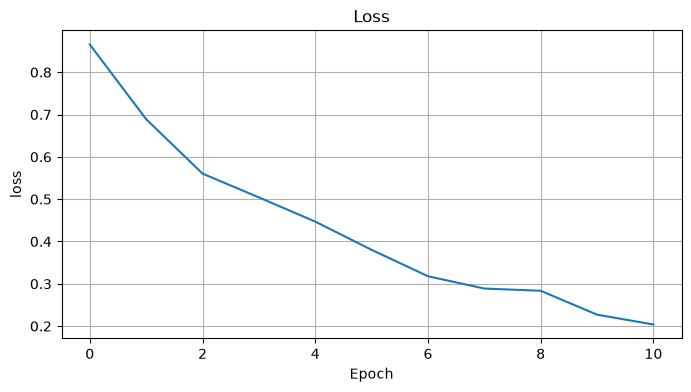

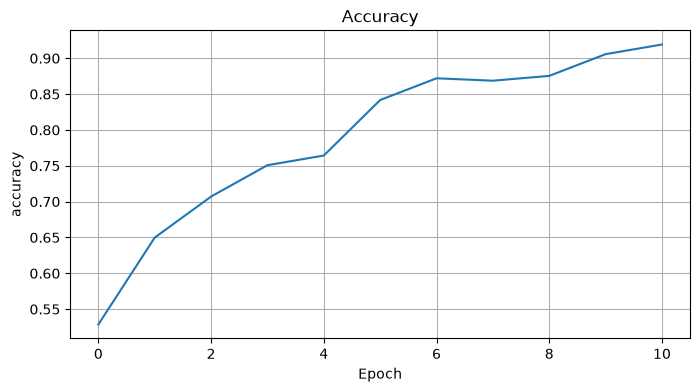

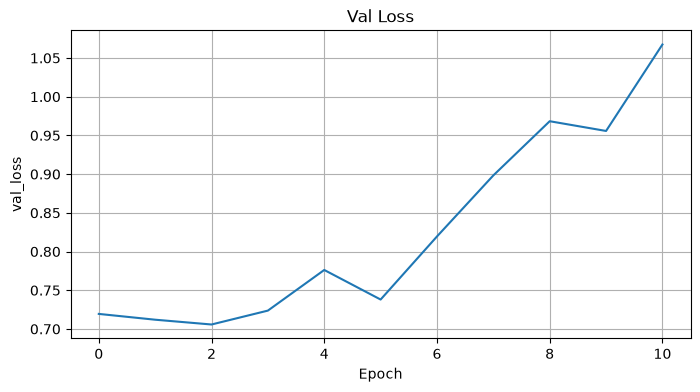

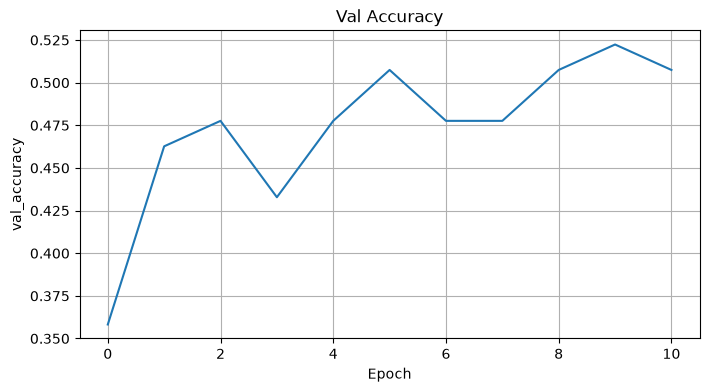

In [22]:
if selected_history_file is not None:

    for key in history_data.files:

        values = history_data[key]

        if values.ndim == 1:

            plt.figure(
                figsize=(8, 4)
            )

            plt.plot(
                values
            )

            plt.title(
                key.replace(
                    "_",
                    " "
                ).title()
            )

            plt.xlabel(
                "Epoch"
            )

            plt.ylabel(
                key
            )

            plt.grid(
                True
            )

            plt.show()

## Feature Normalization Analysis

Multimodal features are normalized before being passed to the LSTM
model.

This section identifies available normalization and scaler artifacts
used across different training experiments.

In [23]:
normalization_files = sorted(

    list(
        MODELS_DIR.glob(
            "*normalization*.npz"
        )
    )

    +

    list(
        MODELS_DIR.glob(
            "*scaler*.npz"
        )
    )

    +

    list(
        SAVED_MODELS_DIR.glob(
            "*normalization*.npz"
        )
    )

    +

    list(
        SAVED_MODELS_DIR.glob(
            "*scaler*.npz"
        )
    )

)

print(
    f"Normalization artifacts found: "
    f"{len(normalization_files)}"
)

for file in normalization_files:

    print(
        file.relative_to(
            PROJECT_ROOT
        )
    )

Normalization artifacts found: 17
models/deepfake_lipsync_feature_scaler.npz
models/deepfake_lipsync_feature_scaler_baseline.npz
models/deepfake_lipsync_feature_scaler_exp3.npz
models/deepfake_lipsync_feature_scaler_exp4.npz
models/deepfake_lipsync_feature_scaler_exp5.npz
models/lstm_exp5_normalization.npz
models/lstm_exp6_normalization.npz
saved_models/lstm_exp10_normalization.npz
saved_models/lstm_exp11_normalization.npz
saved_models/lstm_exp12_normalization.npz
saved_models/lstm_exp13_normalization.npz
saved_models/lstm_exp14_normalization.npz
saved_models/lstm_exp15_normalization.npz
saved_models/lstm_exp7_normalization.npz
saved_models/lstm_exp7_scaler.npz
saved_models/lstm_exp8_normalization.npz
saved_models/lstm_exp9_normalization.npz


In [24]:
for file in normalization_files:

    print("\n" + "=" * 70)

    print(
        file.name
    )

    print("=" * 70)

    data = np.load(file)

    for key in data.files:

        array = data[key]

        print(
            f"{key}: "
            f"shape={array.shape}"
        )


deepfake_lipsync_feature_scaler.npz
mean: shape=(173,)
scale: shape=(173,)

deepfake_lipsync_feature_scaler_baseline.npz
mean: shape=(173,)
scale: shape=(173,)

deepfake_lipsync_feature_scaler_exp3.npz
mean: shape=(173,)
scale: shape=(173,)

deepfake_lipsync_feature_scaler_exp4.npz
mean: shape=(173,)
scale: shape=(173,)

deepfake_lipsync_feature_scaler_exp5.npz
mean: shape=(199,)
scale: shape=(199,)

lstm_exp5_normalization.npz
mean: shape=(1, 1, 199)
std: shape=(1, 1, 199)

lstm_exp6_normalization.npz
mean: shape=(1, 1, 199)
std: shape=(1, 1, 199)

lstm_exp10_normalization.npz
mean: shape=(1, 1, 597)
std: shape=(1, 1, 597)

lstm_exp11_normalization.npz
mean: shape=(1, 1, 597)
std: shape=(1, 1, 597)

lstm_exp12_normalization.npz
mean: shape=(1, 1, 597)
std: shape=(1, 1, 597)

lstm_exp13_normalization.npz
mean: shape=(1, 1, 597)
std: shape=(1, 1, 597)

lstm_exp14_normalization.npz
mean: shape=(1, 1, 199)
std: shape=(1, 1, 199)

lstm_exp15_normalization.npz
mean: shape=(1, 1, 398)
std: 

## Model Artifact Summary

The final section summarizes the machine learning artifacts available
in the project.

These artifacts include:

- Trained Keras models
- Training history
- Feature normalization files
- Validation threshold artifacts
- Test prediction artifacts

In [25]:
threshold_files = sorted(

    list(
        MODELS_DIR.glob(
            "*threshold*"
        )
    )

    +

    list(
        SAVED_MODELS_DIR.glob(
            "*threshold*"
        )
    )

)

prediction_files = sorted(

    list(
        SAVED_MODELS_DIR.glob(
            "*prediction*.npz"
        )
    )

)

print("=" * 60)

print(
    "PROJECT MODEL ARTIFACT SUMMARY"
)

print("=" * 60)

print(
    "\nKeras Models:",
    len(model_files)
)

print(
    "Training History Files:",
    len(history_files)
)

print(
    "Normalization Files:",
    len(normalization_files)
)

print(
    "Threshold Files:",
    len(threshold_files)
)

print(
    "Prediction Files:",
    len(prediction_files)
)

PROJECT MODEL ARTIFACT SUMMARY

Keras Models: 21
Training History Files: 2
Normalization Files: 17
Threshold Files: 7
Prediction Files: 6


# Conclusion

This notebook analyzed the trained machine learning artifacts used in
the Multimodal Deepfake Lip-Sync Anomaly Detector.

The analysis included:

- Identification of available trained LSTM models
- Inspection of the primary deployed model
- Model architecture analysis
- Layer-by-layer inspection
- Parameter analysis
- Temporal input analysis
- Model output analysis
- Training history inspection
- Training metric visualization
- Feature normalization artifact inspection
- Saved model artifact summary

The project uses a multimodal temporal learning approach in which
visual lip movement information and audio features are processed as a
sequence by an LSTM-based deep learning model.

The saved experimental artifacts demonstrate the iterative model
development and evaluation process carried out during the project.

In [26]:
print("=" * 60)

print(
    "MODEL ANALYSIS COMPLETE"
)

print("=" * 60)

print(
    "Primary model:",
    FINAL_MODEL_PATH.name
)

print(
    "Input shape:",
    model.input_shape
)

print(
    "Output shape:",
    model.output_shape
)

print(
    "Total parameters:",
    f"{model.count_params():,}"
)

print(
    "\nNotebook analysis completed successfully."
)

print("=" * 60)

MODEL ANALYSIS COMPLETE
Primary model: deepfake_lipsync_lstm.keras
Input shape: (None, 30, 173)
Output shape: (None, 1)
Total parameters: 26,977

Notebook analysis completed successfully.
